In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
from scipy import stats

# Deep Learning imports for GNN
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Libraries imported successfully!
PyTorch version: 2.9.1+cpu
CUDA available: False


## 1. Load Real Crypto Data

In [2]:
# ─── Load real crypto returns from Excel ───────────────────────────────
EXCEL_FILE = 'crypto_data_real.xlsx'

df_raw = pd.read_excel(EXCEL_FILE, sheet_name='Returns', index_col=0)
df_raw.index = pd.to_datetime(df_raw.index)
df_raw.sort_index(inplace=True)

print(f'Raw data shape : {df_raw.shape}')
print(f'Date range     : {df_raw.index.min().date()} -> {df_raw.index.max().date()}')
print(f'Assets         : {df_raw.columns.tolist()}')

# ─── Drop 'USDT' (stablecoin, near-zero returns – not useful) ───────────
df_raw = df_raw.drop(columns=['USDT'], errors='ignore')

# ─── Drop rows where ANY asset has return == 0.0 (pre-listing period) ───
# Zero values indicate the coin had not yet been listed on the exchange.
# We keep only the period where ALL remaining coins have actual data.
mask_all_active = (df_raw != 0).all(axis=1)
df_returns = df_raw[mask_all_active].copy()

print(f'\nAfter filtering : {df_returns.shape}')
print(f'Clean date range: {df_returns.index.min().date()} -> {df_returns.index.max().date()}')
print(f'Assets kept     : {df_returns.columns.tolist()}')
print(f'\nBasic stats:')
print(df_returns.describe().round(4))

Raw data shape : (763, 10)
Date range     : 2017-09-15 -> 2019-10-17
Assets         : ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']

After filtering : (706, 9)
Clean date range: 2017-11-10 -> 2019-10-17
Assets kept     : ['BTC', 'ETH', 'XRP', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']

Basic stats:
            BTC       ETH       XRP       BCH       LTC       BNB       EOS  \
count  706.0000  706.0000  706.0000  706.0000  706.0000  706.0000  706.0000   
mean     0.0002   -0.0008    0.0005   -0.0016   -0.0002    0.0032    0.0013   
std      0.0434    0.0527    0.0680    0.0752    0.0591    0.0645    0.0737   
min     -0.1846   -0.2069   -0.3520   -0.4096   -0.2119   -0.3424   -0.3015   
25%     -0.0173   -0.0237   -0.0267   -0.0336   -0.0287   -0.0258   -0.0306   
50%      0.0016   -0.0003   -0.0025   -0.0038   -0.0028    0.0000   -0.0005   
75%      0.0186    0.0248    0.0203    0.0256    0.0275    0.0310    0.0297   
max      0.2251    0.2347    0.6069    0.43

## 2. Helper Functions

In [3]:
def apply_rmt_filter(returns_data):
    """Apply Random Matrix Theory filtering to remove noise eigenmodes."""
    T, N = returns_data.shape
    Q = T / N
    C = np.corrcoef(returns_data.T)
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    significant_mask = eigenvalues > lambda_plus
    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered

def build_mst(correlation_matrix):
    """Convert correlation matrix to distance matrix (for MST)."""
    distance_matrix = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix

def compute_eigenvector_centrality(distance_matrix):
    """Compute eigenvector centrality from distance matrix."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    return centrality

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """Graph-based diversification via Maximum Independent Set."""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def calculate_var(returns, confidence=0.95):
    """Calculate Value at Risk."""
    return np.percentile(returns, (1-confidence)*100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Calculate Rachev Ratio (ETL upper / ETL lower)."""
    threshold_upper = np.percentile(returns, (1-alpha)*100)
    threshold_lower = np.percentile(returns, alpha*100)
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    """Calculate Maximum Drawdown."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()

def diebold_mariano_test(returns_a, returns_b, h=1):
    """
    Diebold-Mariano test: tests whether the difference in returns
    between two strategies is statistically significant.
    H0: no difference in predictive accuracy.
    """
    T = len(returns_a)
    d = returns_a - returns_b
    d_mean = np.mean(d)
    def autocovariance(xi, x_mean, k):
        T_ = len(xi)
        if T_ <= k: return 0
        return np.sum((xi[:T_-k] - x_mean) * (xi[k:] - x_mean)) / T_
    var_d = autocovariance(d, d_mean, 0)
    for i in range(1, h):
        var_d += 2 * autocovariance(d, d_mean, i)
    dm_stat = d_mean / np.sqrt(np.abs(var_d) / T) if var_d != 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

print('Helper functions defined.')

Helper functions defined.


## 3. Graph Neural Network Architecture

In [4]:
class CorrelationGNN(nn.Module):
    """
    2-layer Graph Convolutional Network.
    Learns node embeddings from asset features;
    pairwise cosine similarity used as predicted correlation.
    """
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=8):
        super(CorrelationGNN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return x

    def predict_correlation(self, node_embeddings):
        """Pairwise cosine similarity between node embeddings."""
        n = node_embeddings.shape[0]
        corr_matrix = torch.zeros(n, n)
        for i in range(n):
            for j in range(i+1, n):
                sim = F.cosine_similarity(
                    node_embeddings[i].unsqueeze(0),
                    node_embeddings[j].unsqueeze(0)
                )
                corr_matrix[i, j] = sim
                corr_matrix[j, i] = sim
        return corr_matrix


def create_graph_data(returns_window, corr_threshold=0.3):
    """Build PyG Data object from a returns window."""
    n_assets = returns_window.shape[1]
    mean_ret  = returns_window.mean().values
    vol       = returns_window.std().values
    skew      = returns_window.skew().values
    kurt      = returns_window.kurtosis().values
    x = torch.FloatTensor(np.stack([mean_ret, vol, skew, kurt], axis=1))
    corr_mat = returns_window.corr().values
    edge_list = []
    for i in range(n_assets):
        for j in range(i+1, n_assets):
            if abs(corr_mat[i, j]) > corr_threshold:
                edge_list.append([i, j])
                edge_list.append([j, i])
    if not edge_list:          # fallback: fully connected
        edge_list = [[i, j] for i in range(n_assets) for j in range(n_assets) if i != j]
    edge_index = torch.LongTensor(edge_list).t().contiguous()
    y = torch.FloatTensor(corr_mat)
    return Data(x=x, edge_index=edge_index, y=y)


def train_gnn(model, data, epochs=50, lr=0.01):
    """Train GNN to reconstruct the correlation matrix."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        embeddings = model(data.x, data.edge_index)
        pred_corr  = model.predict_correlation(embeddings)
        loss = criterion(pred_corr, data.y)
        loss.backward()
        optimizer.step()
    return model

print('GNN architecture defined.')

GNN architecture defined.


## 4. Strategy Implementations

In [5]:
class PortfolioStrategy:
    """Base class for portfolio strategies."""
    def __init__(self, name):
        self.name = name
        self.weights_history = []
        self.returns_history = []

    def get_weights(self, returns_data):
        raise NotImplementedError

    def calculate_portfolio_return(self, weights, future_returns):
        return np.dot(weights, future_returns)


class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


class ClassicalMarkowitz(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        mu  = returns_data.mean().values
        Sigma = returns_data.cov().values
        def objective(w): return w @ Sigma @ w
        constraints = [
            {'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()},
        ]
        bounds = tuple((0, 1) for _ in range(n))
        w0 = np.ones(n) / n
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0


class GlassoMarkowitz(PortfolioStrategy):
    def __init__(self, name='Glasso Markowitz', alpha=0.01):
        super().__init__(name)
        self.alpha = alpha

    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        mu = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV(alphas=[self.alpha], cv=3)
            glasso.fit(returns_data.values)
            Sigma = glasso.covariance_
        except Exception:
            Sigma = returns_data.cov().values
        def objective(w): return w @ Sigma @ w
        constraints = [
            {'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()},
        ]
        bounds = tuple((0, 1) for _ in range(n))
        w0 = np.ones(n) / n
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0


class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name='Network Markowitz', gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        mu    = returns_data.mean().values
        sigma = returns_data.std().values
        C_filtered  = apply_rmt_filter(returns_data)
        dist_matrix = build_mst(C_filtered)
        centrality  = compute_eigenvector_centrality(dist_matrix)
        Sigma_filt  = np.outer(sigma, sigma) * C_filtered
        def objective(w):
            return w @ Sigma_filt @ w + self.gamma * np.sum(centrality * w)
        constraints = [
            {'type': 'eq',  'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq','fun': lambda w: w @ mu - mu.mean()},
        ]
        bounds = tuple((0, 1) for _ in range(n))
        w0 = np.ones(n) / n
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0


class GraphDiversification(PortfolioStrategy):
    def __init__(self, name='Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        all_assets = returns_data.columns.tolist()
        selected   = get_assets_graph_diversify(returns_data, self.corr_threshold)
        weights = np.zeros(n)
        if selected:
            for asset in selected:
                weights[all_assets.index(asset)] = 1.0 / len(selected)
        else:
            weights = np.ones(n) / n
        return weights


class GNNGraphDiversification(PortfolioStrategy):
    def __init__(self, name='GNN Graph Diversification', base_threshold=0.4, train_epochs=30):
        super().__init__(name)
        self.base_threshold = base_threshold
        self.train_epochs   = train_epochs
        self.gnn_model      = CorrelationGNN(input_dim=4, hidden_dim=16, output_dim=8)

    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        all_assets = returns_data.columns.tolist()
        graph_data = create_graph_data(returns_data, corr_threshold=0.3)
        self.gnn_model = train_gnn(self.gnn_model, graph_data,
                                   epochs=self.train_epochs, lr=0.01)
        self.gnn_model.eval()
        with torch.no_grad():
            embeddings = self.gnn_model(graph_data.x, graph_data.edge_index)
            pred_corr  = self.gnn_model.predict_correlation(embeddings)
        pred_np = pred_corr.numpy()
        upper   = pred_np[np.triu_indices(n, k=1)]
        dyn_thr = np.clip(np.mean(np.abs(upper)) + 0.5*np.std(np.abs(upper)), 0.3, 0.7)
        G = nx.Graph()
        assets_sorted = list(returns_data.mean().sort_values(ascending=False).index)
        G.add_nodes_from(assets_sorted)
        for i, a1 in enumerate(assets_sorted):
            for a2 in assets_sorted[i+1:]:
                i1, i2 = all_assets.index(a1), all_assets.index(a2)
                if abs(pred_np[i1, i2]) > dyn_thr:
                    G.add_edge(a1, a2)
        selected = list(nx.approximation.maximum_independent_set(G))
        weights  = np.zeros(n)
        if selected:
            for asset in selected:
                weights[all_assets.index(asset)] = 1.0 / len(selected)
        else:
            weights = np.ones(n) / n
        return weights

print('Strategy classes defined.')

Strategy classes defined.


## 5. Backtesting Framework

In [6]:
def backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7,
                       transaction_cost=0.001):
    portfolio_returns = []
    weights_history   = []
    dates             = []
    for i in range(window_size, len(df_returns), rebalance_freq):
        train = df_returns.iloc[i-window_size:i]
        w = strategy.get_weights(train)
        weights_history.append(w)
        test_end  = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]
        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and portfolio_returns:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])
    results_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    results_df['cumulative_return'] = (1 + results_df['return']).cumprod()
    return {
        'strategy': strategy.name,
        'returns':  np.array(portfolio_returns),
        'cumulative_returns': results_df['cumulative_return'].values,
        'dates':    dates,
        'weights_history': weights_history,
        'results_df': results_df,
    }


def calculate_metrics(result):
    returns  = result['returns']
    cum_ret  = result['cumulative_returns']
    ann_ret  = np.mean(returns) * 252
    ann_vol  = np.std(returns)  * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0
    var_95   = calculate_var(returns, 0.95)
    rachev   = calculate_rachev_ratio(returns, 0.10)
    max_dd   = calculate_max_drawdown(cum_ret)
    tot_ret  = cum_ret[-1] - 1
    return {
        'Strategy':             result['strategy'],
        'Total Return (%)':     round(tot_ret  * 100, 2),
        'Annual Return (%)':    round(ann_ret  * 100, 2),
        'Annual Volatility (%)':round(ann_vol  * 100, 2),
        'Sharpe Ratio':         round(sharpe,   4),
        'VaR 95% (%)':          round(var_95   * 100, 4),
        'Rachev Ratio':         round(rachev,   4),
        'Max Drawdown (%)':     round(max_dd   * 100, 2),
    }

print('Backtesting framework defined.')

Backtesting framework defined.


## 6. Run Backtests

In [7]:
strategies = [
    EquallyWeighted('Equally Weighted'),
    ClassicalMarkowitz('Classical Markowitz'),
    GlassoMarkowitz('Glasso Markowitz', alpha=0.01),
    NetworkMarkowitz('Network Markowitz (gamma=0)',   gamma=0),
    NetworkMarkowitz('Network Markowitz (gamma=1.0)', gamma=1.0),
    GraphDiversification('Graph Diversification (theta=0.4)', corr_threshold=0.4),
    GraphDiversification('Graph Diversification (theta=0.5)', corr_threshold=0.5),
    GNNGraphDiversification('GNN Graph Diversification (30 epochs)', train_epochs=30),
    GNNGraphDiversification('GNN Graph Diversification (50 epochs)', train_epochs=50),
]

print('Running backtests on REAL CRYPTO DATA...')
print(f'Assets : {df_returns.columns.tolist()}')
print(f'Period : {df_returns.index.min().date()} -> {df_returns.index.max().date()}')
print(f'Obs    : {len(df_returns)} trading days\n')

results = {}
for strategy in strategies:
    print(f'Testing: {strategy.name}...')
    result = backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7)
    results[strategy.name] = result
    print(f'  Done')

print('\nAll backtests completed!')

Running backtests on REAL CRYPTO DATA...
Assets : ['BTC', 'ETH', 'XRP', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']
Period : 2017-11-10 -> 2019-10-17
Obs    : 706 trading days

Testing: Equally Weighted...
  Done
Testing: Classical Markowitz...
  Done
Testing: Glasso Markowitz...
  Done
Testing: Network Markowitz (gamma=0)...
  Done
Testing: Network Markowitz (gamma=1.0)...
  Done
Testing: Graph Diversification (theta=0.4)...
  Done
Testing: Graph Diversification (theta=0.5)...
  Done
Testing: GNN Graph Diversification (30 epochs)...
  Done
Testing: GNN Graph Diversification (50 epochs)...
  Done

All backtests completed!


## 7. Performance Metrics

In [8]:
metrics_list = [calculate_metrics(r) for r in results.values()]
metrics_df   = pd.DataFrame(metrics_list).set_index('Strategy')

print('PERFORMANCE METRICS')
print('='*100)
print(metrics_df.to_string())
print('='*100)

# Highlight best per column
metrics_df

PERFORMANCE METRICS
                                       Total Return (%)  Annual Return (%)  Annual Volatility (%)  Sharpe Ratio  VaR 95% (%)  Rachev Ratio  Max Drawdown (%)
Strategy                                                                                                                                                    
Equally Weighted                                 -78.43             -40.43                  70.72       -0.5717      -7.6072        0.8401            -87.80
Classical Markowitz                              -70.71             -35.31                  58.53       -0.6033      -6.3367        0.8272            -76.57
Glasso Markowitz                                 -70.71             -35.31                  58.53       -0.6033      -6.3367        0.8272            -76.57
Network Markowitz (gamma=0)                      -69.62             -33.87                  58.37       -0.5803      -6.5036        0.8434            -77.77
Network Markowitz (gamma=1.0)         

,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,VaR 95% (%),Rachev Ratio,Max Drawdown (%)
Strategy,,,,,,,
Equally Weighted,-78.43,-40.43,70.72,-0.5717,-7.6072,0.8401,-87.80
Classical Markowitz,-70.71,-35.31,58.53,-0.6033,-6.3367,0.8272,-76.57
Glasso Markowitz,-70.71,-35.31,58.53,-0.6033,-6.3367,0.8272,-76.57
Network Markowitz (gamma=0),-69.62,-33.87,58.37,-0.5803,-6.5036,0.8434,-77.77
Network Markowitz (gamma=1.0),-71.67,-27.19,73.29,-0.3710,-7.9452,0.9833,-87.62
Graph Diversification (theta=0.4),-86.74,-49.73,86.68,-0.5737,-8.4900,0.9970,-92.78
Graph Diversification (theta=0.5),-75.17,-22.80,86.75,-0.2629,-8.7056,0.9789,-92.86
GNN Graph Diversification (30 epochs),-88.10,-59.58,79.96,-0.7452,-8.4596,0.8572,-93.19
GNN Graph Diversification (50 epochs),-87.56,-50.32,89.30,-0.5635,-8.7642,1.0473,-93.29


## 8. Statistical Validation (Diebold-Mariano Test)

In [9]:
benchmark_name = 'Classical Markowitz'
gnn_name       = 'GNN Graph Diversification (50 epochs)'

dm_stat, p_val = diebold_mariano_test(
    results[gnn_name]['returns'],
    results[benchmark_name]['returns']
)

print('Diebold-Mariano Test')
print('-' * 50)
print(f'Comparison : {gnn_name}')
print(f'Benchmark  : {benchmark_name}')
print(f'DM Statistic: {dm_stat:.4f}')
print(f'P-Value     : {p_val:.4f}')
print()
if p_val < 0.05:
    print('Result: Significant Difference (alpha=0.05)')
    direction = gnn_name if dm_stat > 0 else benchmark_name
    print(f'Conclusion: {direction} significantly outperforms the other.')
else:
    print('Result: No Significant Difference (alpha=0.05)')
    print('Conclusion: Performance differences may be due to randomness.')
print('-' * 50)

Diebold-Mariano Test
--------------------------------------------------
Comparison : GNN Graph Diversification (50 epochs)
Benchmark  : Classical Markowitz
DM Statistic: -0.4279
P-Value     : 0.6688

Result: No Significant Difference (alpha=0.05)
Conclusion: Performance differences may be due to randomness.
--------------------------------------------------


## 9. Visualization

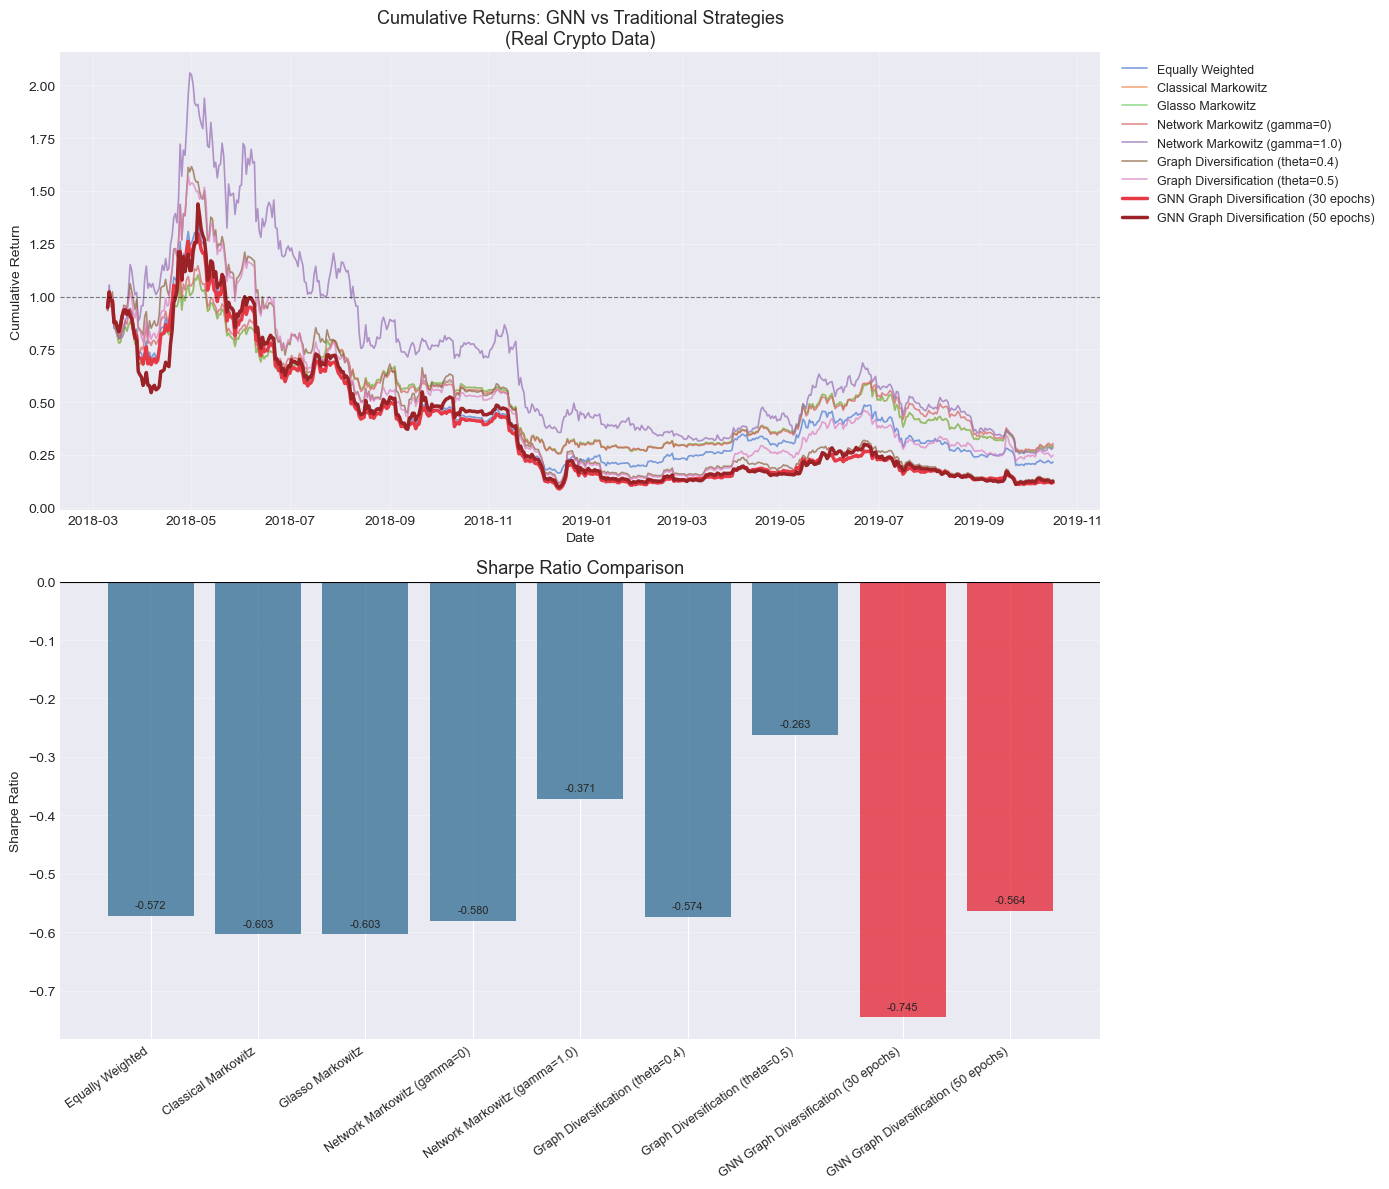

Plot saved as cumulative_returns_real_crypto.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# ── Plot 1: Cumulative Returns ──────────────────────────────────────────
ax = axes[0]
gnn_colors   = ['#e63946', '#9b2226']
other_colors = sns.color_palette('muted', len(strategies) - 2)
gnn_idx = other_idx = 0

for name, res in results.items():
    dates = [d if hasattr(d, 'date') else pd.Timestamp(d) for d in res['dates']]
    if 'GNN' in name:
        ax.plot(dates, res['cumulative_returns'],
                label=name, color=gnn_colors[gnn_idx], linewidth=2.5)
        gnn_idx += 1
    else:
        ax.plot(dates, res['cumulative_returns'],
                label=name, color=other_colors[other_idx],
                linewidth=1.2, alpha=0.7)
        other_idx += 1

ax.set_title('Cumulative Returns: GNN vs Traditional Strategies\n(Real Crypto Data)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# ── Plot 2: Sharpe Ratio Bar Chart ──────────────────────────────────────
ax2 = axes[1]
sharpe_vals  = metrics_df['Sharpe Ratio']
bar_colors   = ['#e63946' if 'GNN' in s else '#457b9d' for s in sharpe_vals.index]
bars = ax2.bar(range(len(sharpe_vals)), sharpe_vals.values, color=bar_colors, alpha=0.85)
ax2.set_xticks(range(len(sharpe_vals)))
ax2.set_xticklabels(sharpe_vals.index, rotation=35, ha='right', fontsize=9)
ax2.set_title('Sharpe Ratio Comparison', fontsize=13)
ax2.set_ylabel('Sharpe Ratio')
ax2.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, sharpe_vals.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cumulative_returns_real_crypto.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as cumulative_returns_real_crypto.png')